In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


#Verifica os arquivos anexados pelo kaggle
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


## 1- Importacao das bibliotecas



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)

Importando as bibliotecas:
 - NumPy : Biblioteca para resolver contas rápidas e mexer com listas, vetores e matrizes.
 - Pandas : O Pandas para criar e organizar tabelas de dados (DataFrames).
 - Matplotliv.pyplot : Biblioteca que desenha gráficos e os mostra na tela.

 - train_test_split, cross_val_score : Biblioteca que corta os dados em dois pedaços, uma parte para o modelo treinar e outra parte para testar e ver se ele aprendeu de verdade. E o cross_val_score ele faz a validação cruzada, que testa o modelo várias vezes em pedaços diferentes dos dados para ter certeza de que ele é bom mesmo
 - StandardScaler : Biblioteca que deixa todos os números na mesma medida para que o algoritmo não ache que um atributo é mais importante que o outro só porque tem números maiores.
 - Pipeline : Ele junta a etapa de arrumar os dados e padronizar com a etapa de treinar o modelo.
 - SVC : É a inteligência artificial que vai aprender a separar as espécies de flores e traçar a linha de decisão entre elas.
 - accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay : accuracy_score ele calcula a porcentagem geral de acertos do modelo, classification_report ele mostra um relatório completo com detalhes de precisão, revocação e nota geral, confusion_matrix ele monta a tabela mostrando onde o modelo acertou e onde ele se confundiu entre as espécies, ConfusionMatrixDisplay ele pega essa tabela de erros e desenha num gráfico colorido e fácil de entender.
   figure.figsize = (8, 5) : Ele define um tamanho padrão 8 de largura por 5 de altura para todos os gráficos que forem gerados no notebook, para que não fiquem gigantes.

## 2- Carregando o dataset a partir do CSV do Kaggle


In [3]:
df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')

# Renomeamos as colunas
df = df.rename(columns={
    "SepalLengthCm": "sepal length (cm)",
    "SepalWidthCm": "sepal width (cm)",
    "PetalLengthCm": "petal length (cm)",
    "PetalWidthCm": "petal width (cm)",
    "Species": "species"
})

df.head()

,Id,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Carregando o Dataset que vem direto do kaggle, e renomeando as colunas do dataset e mostrando na tela.

## 3- Analise Exploratoria de Dados (EDA)
## 3.1- Estrutura Geral

In [4]:
print("Dimensão do dataset:", df.shape)
print("\nNomes das colunas:")
for col in df.columns:
    print("-", col)

print("\nContagem por espécie:")
print(df["species"].value_counts())

Dimensão do dataset: (150, 6)

Nomes das colunas:
- Id
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)
- species

Contagem por espécie:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


O dataset possui 150 linhas e 5 colunas com 4 medidas numéricas + a espécie. O df.columns pega a lista com o nome de todos os cabeçalhos da tabela. O laço for passa por cada um desses nomes e imprime na tela com um hífen na frente para organizar em lista. E o value_counts() conta quantas vezes cada categoria aparece dentro da coluna species.

### 3.2 Estatísticas descritivas

In [5]:
df.describe()

,Id,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


A tabela acima mostra média, desvio-padrão, mínimo, máximo e quartos de cada medida. Isso ajuda a identificar a escala de cada variável informação. Ele foi utilizado para entender rápido o tamanho geral de cada parte das flores e ver como os números variam sem ter que olhar as 150 linhas uma por uma.


### 3.3 Distribuição das classes

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


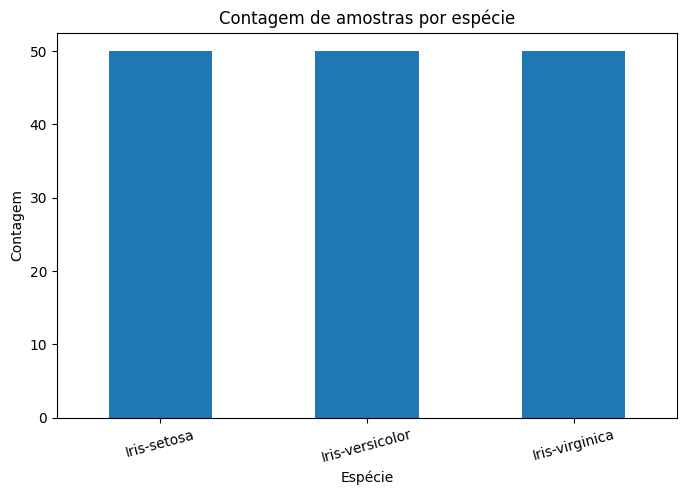

In [6]:
species_counts = df["species"].value_counts()
print(species_counts)

species_counts.plot(kind="bar")
plt.title("Contagem de amostras por espécie")
plt.xlabel("Espécie")
plt.ylabel("Contagem")
plt.xticks(rotation=15)
plt.show()

O dataset é perfeitamente balanceado: 50 amostras para cada uma das três espécies Iris-setosa, Iris-versicolor, Iris-virginica. Esse equilíbrio é útil porque evita problemas de desbalanceamento de classes durante o treinamento e a avaliação do modelo. O value_counts() pega a coluna species e soma quantas flores de cada espécie aparecem na tabela. O print mostra esses números na tela. Pega o resultado dessa contagem e transforma num gráfico de barras por isso o kind="bar" e depois para deixar o gráfico organizado e explicativo.




### 3.4 Distribuição das variáveis numéricas

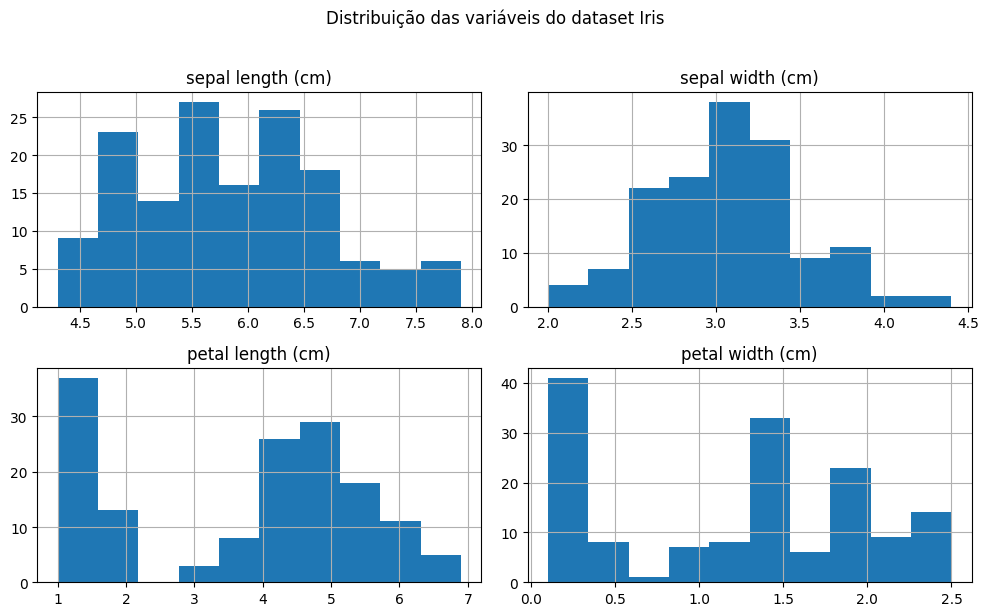

In [7]:


df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]].hist(figsize=(10, 6))
plt.suptitle("Distribuição das variáveis do dataset Iris", y=1.02)
plt.tight_layout()
plt.show()

O método .hist() cria de uma vez só quatro gráficos de barra, um para cada característica numérica das flores sepal length, sepal width, petal length e petal width. O parâmetro figsize=(10, 6) define o tamanho da imagem final 10 de largura por 6 de altura. E o suptitle adiciona um título geral no topo da figura inteira. O parâmetro y=1.02 que empurra o texto um pouquinho para cima. O plt.tight_layout() ajusta o espaçamento interno entre os quatro gráficos.

### 3.5 Relação entre variáveis, por espécie

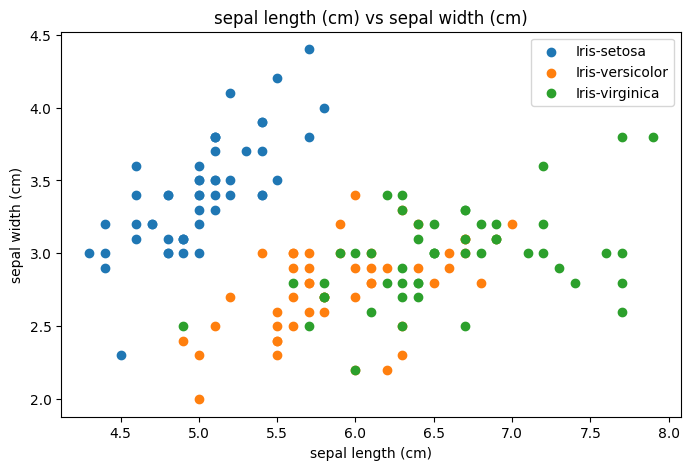

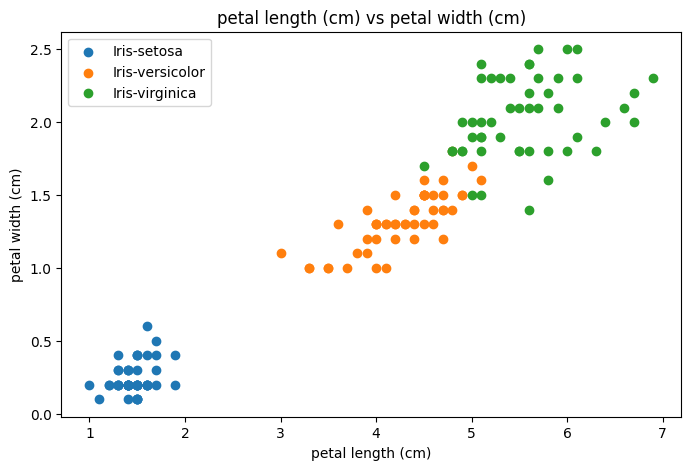

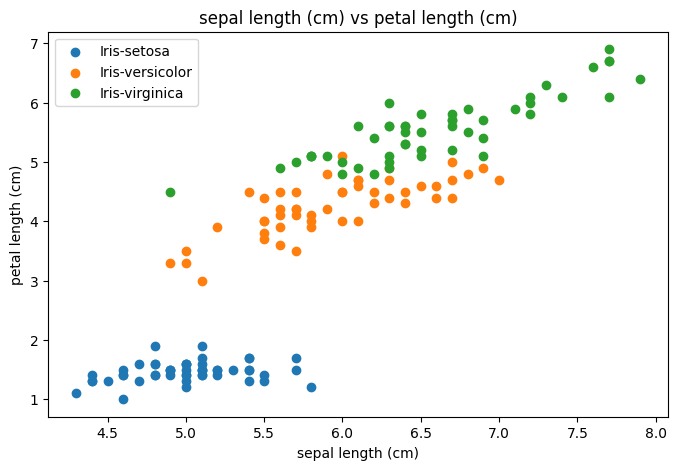

In [8]:
pairs = [
    ("sepal length (cm)", "sepal width (cm)"),
    ("petal length (cm)", "petal width (cm)"),
    ("sepal length (cm)", "petal length (cm)")
]

for xcol, ycol in pairs:
    plt.figure()
    for species in df["species"].unique():
        subset = df[df["species"] == species]
        plt.scatter(subset[xcol], subset[ycol], label=species)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs {ycol}")
    plt.legend()
    plt.show()

Criando a lista de duplas para comparar isso para deixar organizado quais atributos das flores serão comparados de uma só vez, sem precisar duplicar código. Rodando o laço para cada dupla para fazer o computador criar os três gráficos em sequência de forma automática. Abrindo uma janela de gráfico nova com o plt.figure() isso para que o gráfico da vez não seja desenhado por cima do anterior. Depois separa os dados por espécie o df"species".unique() descobre os nomes das três espécies setosa, versicolor, virginica. O subset filtra a tabela para pegar apenas as flores daquela espécie específica na volta do laço e utilizando o plt.scatter(subset[xcol], subset[ycol], label=species) desenha os pontos no gráfico usando a primeira medida no eixo x e a segunda no eixo y e depois adicionando títulos, legenda e mostrando na tela.

-


## 4. Pré-processamento

### 4.1 Separando variáveis de entrada (X) e alvo (y)

In [9]:
features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']

X = df[features]
y = df["species"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (150, 4)
Formato de y: (150,)


### 4.2 Divisão treino/teste


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

X_train: (120, 4)
X_test : (30, 4)

Distribuição em y_train:
species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Distribuição em y_test:
species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


Cortando os dados em Treino e Teste - train_test_split ele separa as entradas x e as respostas y em quatro partes os dados para o modelo treinar X_train e y_train e os dados trancados para a teste X_test e y_test e depois conferir o tamanho de cada fatia de dados.

## 5. Modelo — Support Vector Machine (SVM)

O SVM o um classificador que busca o hiperplano que maximiza a margem
entre as classes. Como ele é sensível à escala das variáveis, usamos um
Pipeline com StandardScaler, garantindo que a padronização seja
ajustada apenas nos dados de treino. E comparamos dois kernels: linear e RBF.


### 5.1 SVM com kernel linear

In [11]:
#SVM kernel linear teste
pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, random_state=42))
])

pipeline_linear.fit(X_train, y_train)

y_pred_linear = pipeline_linear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia (SVM linear): {acc_linear:.4f}")
print("Relatório de classificação — SVM linear\n")
print(classification_report(y_test, y_pred_linear))

Acurácia (SVM linear): 1.0000
Relatório de classificação — SVM linear

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



Montando o Pipeline do modelo porque é a forma mais segura de organizar o código porque garante que a padronização das escalas seja calculada usando só os dados de treino, primeiro ajusta a escala das variáveis com o StandardScaler e em seguida chama o classificador SVC usando uma linha reto de separação (kernel="linear"). E treinando o modelo com  pipeline\_linear.fit(X\_train, y\_train) entrega as medidas das flores de treino X_train junto com as espécies reais de cada uma y_train para o algoritmo aprender. E agora Fazendo as adivinhações nos dados de teste com o .predict que ele compara as respostas previstas pelo modelo (y_pred_linear) com os gabaritos reais (y_test) e calcula a porcentagem geral de acertos. E depois Gerando o relatório detalhado com classification_report.

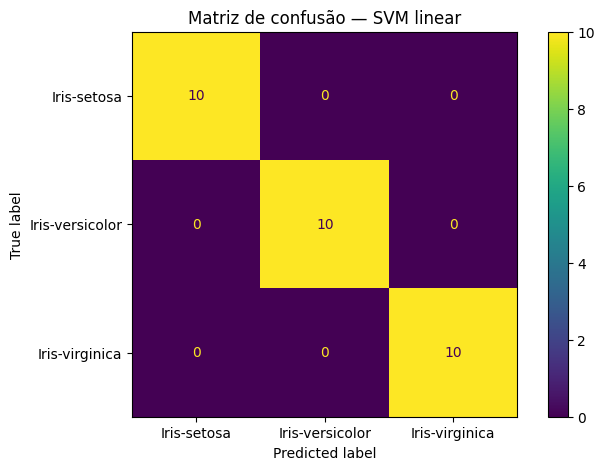

In [12]:
cm_linear = confusion_matrix(y_test, y_pred_linear, labels=sorted(y.unique())) # VER ISSO
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=sorted(y.unique()))
disp.plot()
plt.title("Matriz de confusão — SVM linear")

plt.show()

Primeiro alculando os acertos e erros com confusion_matrix, que compara as espécies reais das flores de teste y_test com o que o modelo adivinhou y_pred_linear. O trecho labels=sorted(y.unique() pega o nome das espécies e coloca em ordem alfabética setosa, versicolor, virginica. E com o disp = ConfusionMatrixDisplay( confusion_matrix=cm_linear, display_labels=sorted(y.unique())) ele pega os números brutos da matriz calculada cm_linear e associa com o nome correto das flores display_labels para montar a figura gráfica. E Desenha o gráfico colorido com o disp.plot() e depois escrevendo o titulo no topo do grafico e mostrando a imagem pronta na tela.

### 5.2 SVM com kernel RBF (não linear)

In [13]:
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

pipeline_rbf.fit(X_train, y_train)
y_pred_rbf = pipeline_rbf.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia (SVM RBF): {acc_rbf:.4f}")
print("Relatório de classificação — SVM com kernel RBF\n")
print(classification_report(y_test, y_pred_rbf))

Acurácia (SVM RBF): 0.9667
Relatório de classificação — SVM com kernel RBF

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



Montando o Pipeline do modelo RBF que primeiro ele ajusta a escala das variáveis com o StandardScaler ele calculado só em cima dos dados de treino, pela mesma razão de segurança do modelo linear, e em seguida chama o classificador SVC, mas agora com kernel="rbf" em vez de traçar uma linha reta para separar as espécies, o modelo passa a poder desenhar uma fronteira curva, capaz de capturar relações não lineares entre as medidas das flores. O gamma="scale" que controla o quanto essa curva se dobra ao redor dos pontos e o scikit-learn ele calcula esse valor automaticamente com base na variância dos dados. Treinando o modelo com pipeline_rbf.fit(X_train, y_train) ele entrega as mesmas medidas de treino X_train junto com as espécies reais y_train, só que agora quem aprende é a versão RBF do SVM. Fazendo as adivinhações nos dados de teste com .predict, gera y_pred_rbf as espécies que o modelo RBF acha que cada flor de teste é, a partir só das medidas, sem nunca ter visto o gabarito dessas flores. E Calculando a acurácia com accuracy_score(y_test, y_pred_rbf), compara as respostas previstas (y_pred_rbf) com os gabaritos reais (y_test) e retorna a porcentagem geral de acertos guardado em acc_rbf e impresso com 4 casas decimais. E depois gerando o relatório detalhado com classification_report, que por espécie mostra precisão da setosa, versicolor e virginica, em vez de só uma média geral.

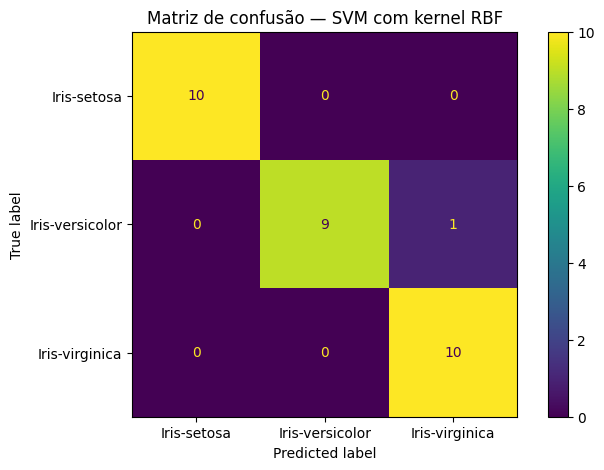

In [14]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=sorted(y.unique())) #VER ISSO
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=sorted(y.unique()))
disp.plot()
plt.title("Matriz de confusão — SVM com kernel RBF")

plt.show()

Calculando os acertos e erros com confusion_matrix, compara de novo y_test com y_pred_rbf, mas agora célula por célula: quantas versicolor reais o modelo acertou como versicolor, quantas confundiu com virginica, e assim por diante. O labels=sorted(y.unique() que garante que as linhas e colunas da matriz sigam a ordem alfabética das espécies setosa, versicolor, virginica. Com o disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, display_labels=sorted(y.unique())), ele pega os números brutos da matriz cm_rbf e associa cada linha e coluna ao nome certo da espécie. E depois gerando o relatório detalhado com classification_report, que por espécie mostra precisão da setosa, versicolor e virginica, em vez de só uma média geral.

## 6. Validação cruzada

Para confirmar que o desempenho não depende só de uma divisão específica
de treino/teste, aplicamos validação cruzada com 5 folds nos dois modelos.

In [15]:
scores_linear = cross_val_score(pipeline_linear, X, y, cv=5)
scores_rbf = cross_val_score(pipeline_rbf, X, y, cv=5)

print(f"SVM linear — média: {scores_linear.mean():.4f} | desvio-padrão: {scores_linear.std():.4f}")
print(f"SVM RBF    — média: {scores_rbf.mean():.4f} | desvio-padrão: {scores_rbf.std():.4f}")

SVM linear — média: 0.9667 | desvio-padrão: 0.0298
SVM RBF    — média: 0.9667 | desvio-padrão: 0.0211


Aqui roda a validação cruzada nos dois modelos cross_val_score ocomando cross_val_score pega a base completa de dados X e y e divide em 5 partes cv=5, rodando o teste 5 vezes seguidas para o SVM linear e depois para o SVM RBF. Depois soma as 5 notas de acurácia obtidas em cada rodada e calcula a média aritmética com o .mean() e ver os acertos para o modelo linear e para o RBF e depois medir a variação com o .std() que calcula o desvio padrão das notas das 5 dobras.

## 7. Comparação final entre os modelos

In [16]:
comparacao = pd.DataFrame({
    "Modelo": ["SVM linear", "SVM não linear (RBF)"],
    "Acurácia no teste": [acc_linear, acc_rbf],
    "Acurácia média CV": [scores_linear.mean(), scores_rbf.mean()],
    "Desvio-padrão CV": [scores_linear.std(), scores_rbf.std()]
})
comparacao

,Modelo,Acurácia no teste,Acurácia média CV,Desvio-padrão CV
0,SVM linear,1.000000,0.966667,0.029814
1,SVM não linear (RBF),0.966667,0.966667,0.021082


Primeiro montamos a tabela pd.DataFrame e nomeamos os modelos para que depois colocamos as notas do teste "Acurácia no teste" e depois colocando as médias da validação cruzada que ele Pega a média de acertos das 5 dobras da validação cruzada de cada modelo .mean() e coloca na terceira coluna. E mede o desvio padrão que pega os resultados da validação cruzada e mostra a tabela comparativa estruturada na saída da célula do notebook.